# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [5]:
from astropy import units as u 

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [6]:
distance = 60 * u.kilometer
speed_mps = distance.to(u.meter)
print(f"{speed_mps:.3f}")

60000.000 m


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [9]:
# The Julian Date is the time and fractions since Universal Time on  January 1, 4713 BCE.

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [ ]:
# There is a 13 day difference between the two calendars. 

From the astropy module `time` import `Time` in the cell below.

In [8]:
from astropy.time import Time

Find the Julian Date for **the current time**. 

In [31]:
time = Time.now()
julian_time = time.jd
print(julian_time)

2460735.8934188564


Convert `1969-07-20 20:17:00` to its **Julian Date**.

In [32]:
time = Time("1969-07-20 20:17:00")
julian_time = time.jd
print(julian_time)

2440423.345138889


What historically happened at this date and time?

In [ ]:
# The Moon landing.

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [33]:
from astropy.coordinates import SkyCoord, Galactic, AltAz, EarthLocation

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [37]:
celestial_object = SkyCoord(ra=15*u.degree, dec=-20*u.degree, frame='icrs')
print(celestial_object)

<SkyCoord (ICRS): (ra, dec) in deg
    (15., -20.)>


Convert the object's coordinates from ICSRS to **Galactic**.

In [39]:
celestial_object_galactic = celestial_object.transform_to(Galactic())
print(celestial_object_galactic)

<SkyCoord (Galactic): (l, b) in deg
    (138.76123783, -82.60718782)>


Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [48]:
campbell_hall = EarthLocation(lat=37.8731 * u.deg, lon=-122.2571 * u.deg)
altaz_frame = AltAz(obstime=Time.now(), location=campbell_hall)
celestial_object_altaz = celestial_object.transform_to(altaz_frame)
print(celestial_object_altaz)

<SkyCoord (AltAz: obstime=2025-03-01 09:39:01.038651, location=(-2690526.45121845, -4263055.67677888, 3894335.00598486) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    (323.4843069, -68.58111167)>


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [49]:
from astropy.io import fits

From the astropy module `astropy.utils.data` import `download_file`.

In [50]:
from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [51]:
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [66]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [73]:
with fits.open(image_file) as hdul:
    hdul.info() 
    data = hdul[0].data 
    header = hdul[0].header 
    data_two = hdul[1].data 

Filename: C:\Users\macka\.astropy\cache\download\url\ff6e0b93871033c68022ca026a956d87\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [86]:
hdu_list = fits.open(image_file)
print(np.max(hdu_list[0].data))

22918


With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [87]:
print(np.min(hdu_list[0].data))

3759


## Tables
From the astropy module `astropy.table` import `Table`.

In [88]:
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [93]:
data = Table({'Star': ['Aldebaran', 'Pollux', 'Betelgeuse'],
              'Magnitude': [0.85, 1.16, 0.58],
              'Spectral Type': ['K5III', 'K0III', 'M2lab']})
print(data)

   Star    Magnitude Spectral Type
---------- --------- -------------
 Aldebaran      0.85         K5III
    Pollux      1.16         K0III
Betelgeuse      0.58         M2lab


Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [94]:
data.write('data.fits', format='fits')

Read and print the table in the cell below from the `.fits` file you made.

In [102]:
table = Table.read('data.fits', hdu=1)
print(table)

   Star    Magnitude Spectral Type
---------- --------- -------------
 Aldebaran      0.85         K5III
    Pollux      1.16         K0III
Betelgeuse      0.58         M2lab


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [ ]:
# It's a scatterplot of stars based on temperature and luminosity. 

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [103]:
import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [105]:
df = pd.read_csv('cluster_data.tsv', 
                 skiprows = 44, 
                 sep = ';', 
                 header = None, 
                 index_col = 0, 
                 names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType'],
                 skipfooter = 1, 
                 engine = 'python')

Display the first few rows of the data.

In [145]:
print(df.head(3))

      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [146]:
df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

C:\Users\macka\AppData\Local\Temp\ipykernel_29628\395354793.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)


Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [154]:
df_clean = df_clean.dropna()
df_clean

,Vmag,Plx,B-V,SpType,M_V,SpType2
HIP,,,,,,
10,8.59,10.76,0.489,F6V,3.749061,F6
11,7.34,4.29,0.081,A2,0.502286,A2
12,8.43,4.06,1.484,K4III,1.472630,K4
13,8.80,3.49,1.128,K0III,1.514127,K0
14,7.25,5.11,1.200,K0,0.792105,K0
...,...,...,...,...,...,...
118318,6.99,1.92,1.595,K2,-1.593494,K2
118319,8.23,10.63,0.639,G2V,3.362666,G2
118320,7.59,5.00,0.999,K0,1.084850,K0


Run the cell below. We are converting the datatypes in the columns to floats.

In [155]:
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

# Display dataset summary
print(df_clean.describe())

                Vmag            Plx            B-V           M_V
count  110761.000000  110761.000000  110761.000000  1.107610e+05
mean        8.268414       7.383430       0.697800          -inf
std         1.243314      11.132379       0.483868           NaN
min        -1.440000       0.000000      -0.400000          -inf
25%         7.590000       2.700000       0.344000  2.575647e-01
50%         8.380000       4.740000       0.602000  1.504560e+00
75%         9.050000       8.450000       1.068000  3.050980e+00
max        13.110000     772.330000       5.460000  1.544901e+01


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [156]:
df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


C:\Users\macka\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Describe what the cell above is doing. 

In [112]:
# It takes the absolute magnitude of stars and adds it to the dataframe. 

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [157]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())

['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B9' 'M0' 'F8' 'M1'
 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2' 'A5'
 'M4' 'A7' 'O8' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'B5' 'K8' 'M7'
 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'F1' 'K6' 'O5' 'O4']


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [ ]:
# O represents the hottest and M represents the coldest. 

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [159]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

C:\Users\macka\AppData\Local\Temp\ipykernel_29628\3283638441.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))


Import `matplotlib.pyplot` in the cell below.

In [161]:
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

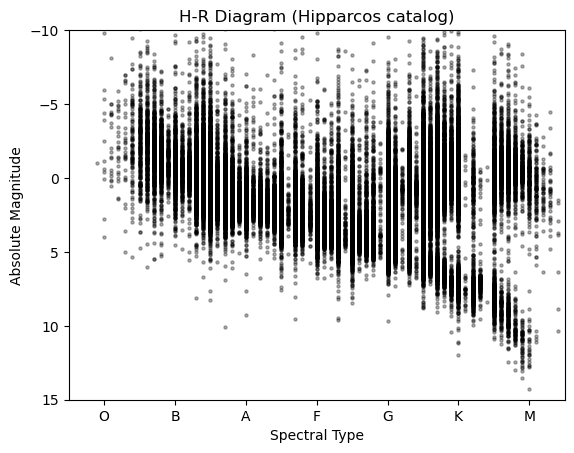

In [165]:
plt.scatter(x = df_clean['SpType2_numeric'], y = df_clean['M_V'], s = 5, alpha = 0.3, c = 'k')
plt.xlim([0, 70]) 
plt.ylim([15, -10]) 
plt.xticks(range(5, 75, 10))
plt.gca().set_xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])
plt.xlabel('Spectral Type')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')
plt.show()

**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

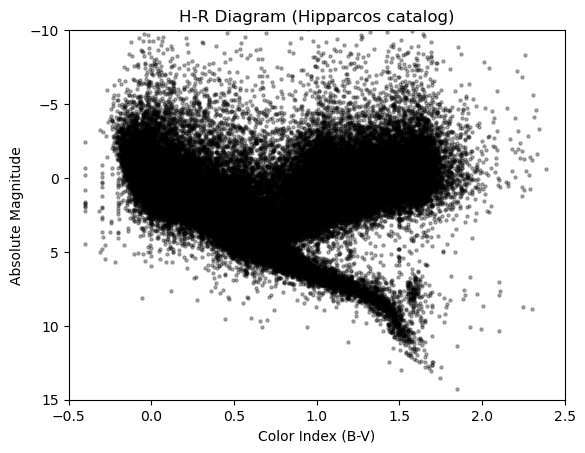

In [166]:
plt.scatter(x = df_clean['B-V'], y = df_clean['M_V'], s = 5, alpha = 0.3, c = 'k')
plt.xlim([-0.5, 2.5]) 
plt.ylim([15, -10])
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')
plt.show()

### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

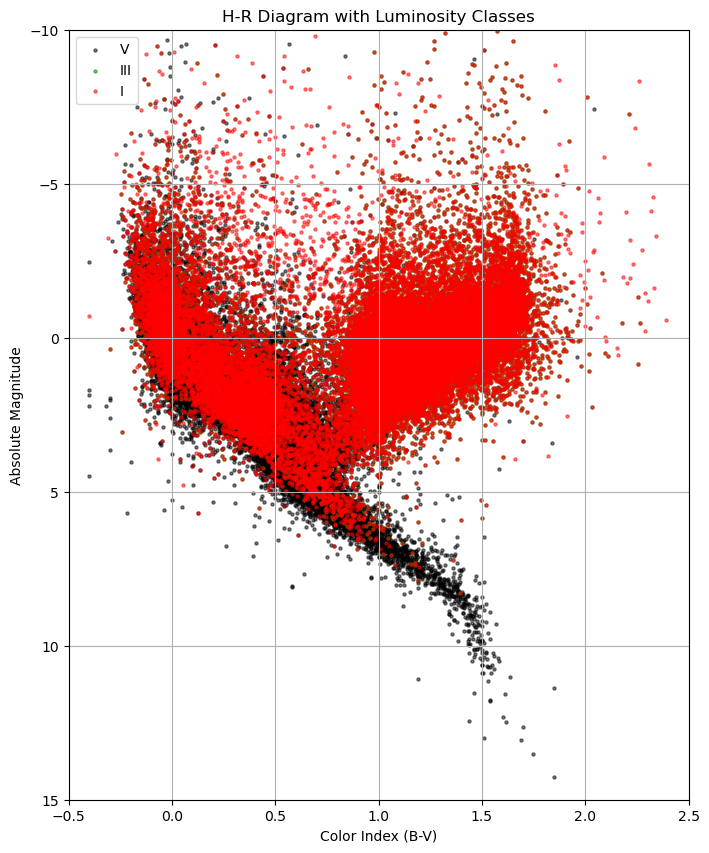

In [167]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()

With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

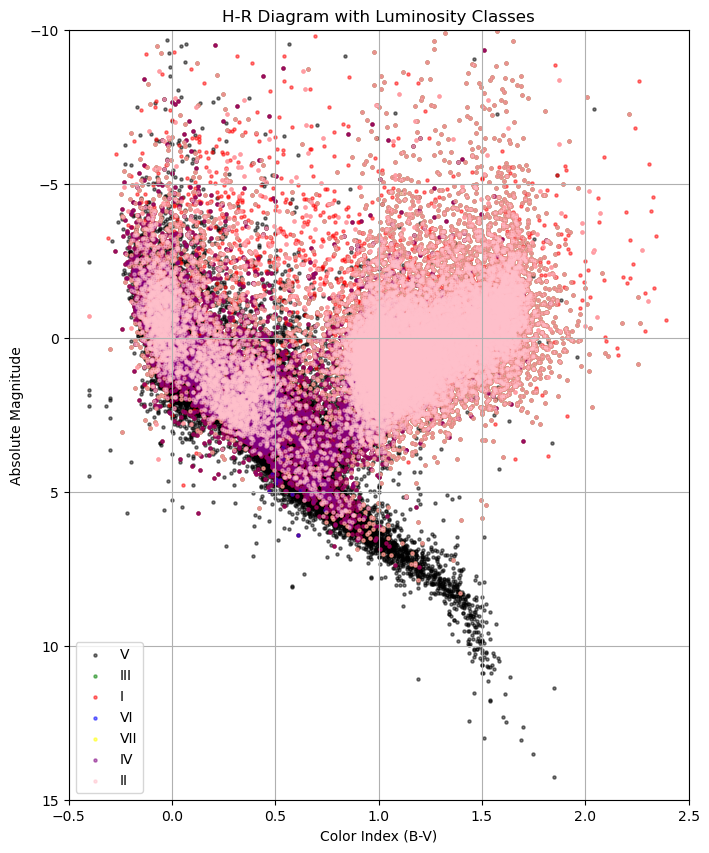

In [172]:
plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants
plot_luminosity_class(df_clean, 'VI', 'blue')  # Subdwarfs
plot_luminosity_class(df_clean, 'VII', 'yellow')  # White dwarf
plot_luminosity_class(df_clean, 'IV', 'purple')  # Subgiants
plot_luminosity_class(df_clean, 'II', 'pink')  # Bright giants
plt.legend()
plt.show()

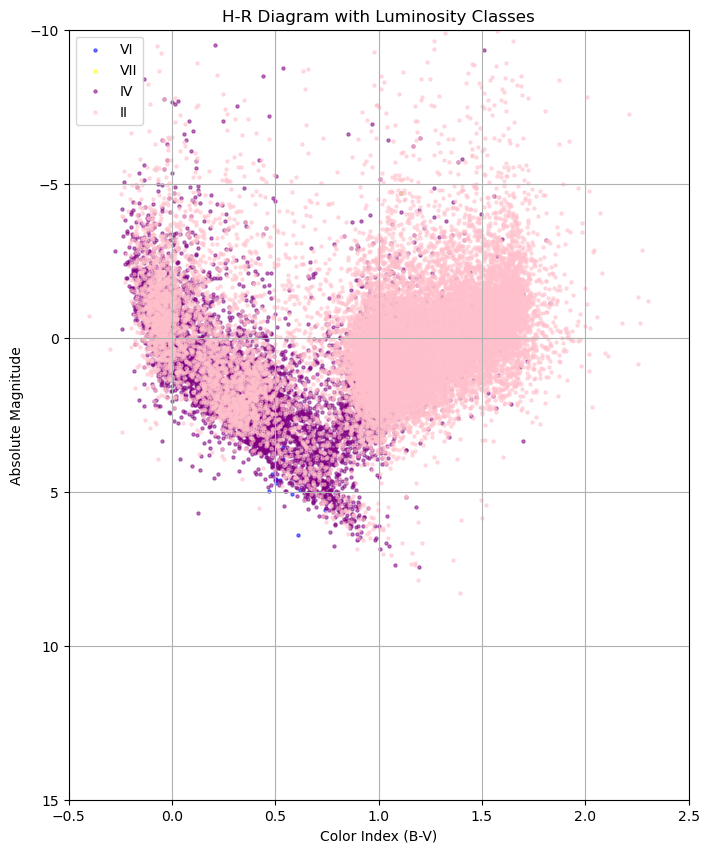

In [173]:
plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'VI', 'blue')  # Subdwarfs
plot_luminosity_class(df_clean, 'VII', 'yellow')  # White dwarf
plot_luminosity_class(df_clean, 'IV', 'purple')  # Subgiants
plot_luminosity_class(df_clean, 'II', 'pink')  # Bright giants
plt.legend()
plt.show()

Submit your FITS file and this notebook to Gradescope!